In [89]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ggsri123/linux-logs/Linux_2k.log
/kaggle/input/datasets/ggsri123/linux-logs/Linux_2k.log_structured.csv
/kaggle/input/datasets/ggsri123/linux-logs/Linux_2k.log_templates.csv


In [90]:
import pandas as pd

In [91]:
data=pd.read_csv("/kaggle/input/datasets/ggsri123/linux-logs/Linux_2k.log_structured.csv")
data

,LineId,Month,Date,Time,Level,Component,PID,Content,EventId,EventTemplate
0,1,Jun,14,15:16:01,combo,sshd(pam_unix),19939.0,authentication failure; logname= uid=0 euid=0 ...,E16,authentication failure; logname= uid=0 euid=0 ...
1,2,Jun,14,15:16:02,combo,sshd(pam_unix),19937.0,check pass; user unknown,E27,check pass; user unknown
2,3,Jun,14,15:16:02,combo,sshd(pam_unix),19937.0,authentication failure; logname= uid=0 euid=0 ...,E16,authentication failure; logname= uid=0 euid=0 ...
3,4,Jun,15,02:04:59,combo,sshd(pam_unix),20882.0,authentication failure; logname= uid=0 euid=0 ...,E18,authentication failure; logname= uid=0 euid=0 ...
4,5,Jun,15,02:04:59,combo,sshd(pam_unix),20884.0,authentication failure; logname= uid=0 euid=0 ...,E18,authentication failure; logname= uid=0 euid=0 ...
...,...,...,...,...,...,...,...,...,...,...
1995,1996,Jul,27,14:41:59,combo,kernel,NaN,pci_hotplug: PCI Hot Plug PCI Core version: 0.5,E83,pci_hotplug: PCI Hot Plug PCI Core version: <*...
1996,1997,Jul,27,14:42:00,combo,kernel,NaN,isapnp: Scanning for PnP cards...,E60,isapnp: Scanning for PnP cards...
1997,1998,Jul,27,14:42:00,combo,kernel,NaN,isapnp: No Plug & Play device found,E59,isapnp: No Plug & Play device found
1998,1999,Jul,27,14:42:00,combo,kernel,NaN,Real Time Clock Driver v1.12,E87,Real Time Clock Driver v<*>.<*>


In [92]:
data.shape

(2000, 10)

In [93]:
data["Level"].value_counts()

Level
combo    2000
Name: count, dtype: int64

In [94]:
data=data.drop(["LineId","Month","Date","Level","Time"],axis=1)
data.shape

(2000, 5)

In [95]:
data

,Component,PID,Content,EventId,EventTemplate
0,sshd(pam_unix),19939.0,authentication failure; logname= uid=0 euid=0 ...,E16,authentication failure; logname= uid=0 euid=0 ...
1,sshd(pam_unix),19937.0,check pass; user unknown,E27,check pass; user unknown
2,sshd(pam_unix),19937.0,authentication failure; logname= uid=0 euid=0 ...,E16,authentication failure; logname= uid=0 euid=0 ...
3,sshd(pam_unix),20882.0,authentication failure; logname= uid=0 euid=0 ...,E18,authentication failure; logname= uid=0 euid=0 ...
4,sshd(pam_unix),20884.0,authentication failure; logname= uid=0 euid=0 ...,E18,authentication failure; logname= uid=0 euid=0 ...
...,...,...,...,...,...
1995,kernel,NaN,pci_hotplug: PCI Hot Plug PCI Core version: 0.5,E83,pci_hotplug: PCI Hot Plug PCI Core version: <*...
1996,kernel,NaN,isapnp: Scanning for PnP cards...,E60,isapnp: Scanning for PnP cards...
1997,kernel,NaN,isapnp: No Plug & Play device found,E59,isapnp: No Plug & Play device found
1998,kernel,NaN,Real Time Clock Driver v1.12,E87,Real Time Clock Driver v<*>.<*>


In [96]:
data["Component"].value_counts()

Component
ftpd               916
sshd(pam_unix)     677
su(pam_unix)       172
kernel              76
klogind             46
logrotate           43
named               16
cups                12
udev                 8
syslogd 1.4.1        7
gdm(pam_unix)        2
xinetd               2
login(pam_unix)      2
gpm                  2
bluetooth            2
network              2
syslog               2
snmpd                1
gdm-binary           1
-- root              1
irqbalance           1
portmap              1
nfslock              1
rpc.statd            1
rpcidmapd            1
random               1
sysctl               1
rc                   1
hcid                 1
sdpd                 1
Name: count, dtype: int64

In [97]:
data["PID"].value_counts()

PID
2306.0     16
12753.0     3
2803.0      3
19085.0     3
12754.0     3
           ..
6601.0      1
6600.0      1
6598.0      1
6597.0      1
7704.0      1
Name: count, Length: 1550, dtype: int64

In [98]:
data["EventId"].value_counts()

EventId
E29     909
E18     351
E101    123
E102    122
E27     117
       ... 
E83       1
E60       1
E59       1
E87       1
E66       1
Name: count, Length: 118, dtype: int64

In [99]:
from sklearn.preprocessing import LabelEncoder

comp_label=LabelEncoder()
data["Component"]=comp_label.fit_transform(data["Component"])

pid_label=LabelEncoder()
data["PID"]=comp_label.fit_transform(data["PID"])

pid_label=LabelEncoder()
data["EventId"]=comp_label.fit_transform(data["EventId"])

In [100]:
data

,Component,PID,Content,EventId,EventTemplate
0,23,690,authentication failure; logname= uid=0 euid=0 ...,26,authentication failure; logname= uid=0 euid=0 ...
1,23,689,check pass; user unknown,38,check pass; user unknown
2,23,689,authentication failure; logname= uid=0 euid=0 ...,26,authentication failure; logname= uid=0 euid=0 ...
3,23,693,authentication failure; logname= uid=0 euid=0 ...,28,authentication failure; logname= uid=0 euid=0 ...
4,23,695,authentication failure; logname= uid=0 euid=0 ...,28,authentication failure; logname= uid=0 euid=0 ...
...,...,...,...,...,...
1995,9,1550,pci_hotplug: PCI Hot Plug PCI Core version: 0.5,100,pci_hotplug: PCI Hot Plug PCI Core version: <*...
1996,9,1550,isapnp: Scanning for PnP cards...,75,isapnp: Scanning for PnP cards...
1997,9,1550,isapnp: No Plug & Play device found,73,isapnp: No Plug & Play device found
1998,9,1550,Real Time Clock Driver v1.12,104,Real Time Clock Driver v<*>.<*>


In [101]:
data["Content"].dtype

dtype('O')

In [102]:
data["EventTemplate"].dtype

dtype('O')

In [103]:
data.isna().sum()

Component        0
PID              0
Content          0
EventId          0
EventTemplate    0
dtype: int64

In [104]:
# from sentence_transformers import SentenceTransformer

# model=SentenceTransformer("all-miniLM-L6-v2")

In [105]:
# cont_embed=model.encode(data["Content"].to_list(),show_progress_bar=True)
# event_embed=model.encode(data["EventTemplate"].to_list(),show_progress_bar=True)

In [106]:
import numpy as np

In [107]:
# cont_embed=np.array(cont_embed,np.float32)
# event_embed=np.array(event_embed,np.float32)

In [108]:
# data["Content"]=cont_embed
# data["EventTemplate"]=event_embed

In [144]:
from sklearn.model_selection import train_test_split

x = data[['Component', 'PID', 'Content','EventId']]
y = data['EventTemplate']

from sklearn.preprocessing import LabelEncoder

scaler=LabelEncoder()
y=scaler.fit_transform(data['EventTemplate'])
x_train_raw, x_test_raw, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [145]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(), 'Content')
    ],
    remainder='passthrough'
)

x_train = preprocessor.fit_transform(x_train_raw)
x_test = preprocessor.transform(x_test_raw)

In [136]:
x_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 24104 stored elements and shape (1600, 601)>

In [146]:
y_train

array([85, 84, 80, ..., 85, 85, 85], shape=(1600,))

In [109]:
# data["Component"] = data["Component"].astype(str)

In [137]:
# vec = TfidfVectorizer()
# x = vec.fit_transform(data["Component"])

In [128]:
x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 986 stored elements and shape (2000, 20)>

In [129]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# vec = TfidfVectorizer()
# y = vec.fit_transform(data["EventTemplate"].astype(str))

In [130]:
y

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10661 stored elements and shape (2000, 324)>

In [147]:
data

,Component,PID,Content,EventId,EventTemplate
0,23,690,authentication failure; logname= uid=0 euid=0 ...,26,authentication failure; logname= uid=0 euid=0 ...
1,23,689,check pass; user unknown,38,check pass; user unknown
2,23,689,authentication failure; logname= uid=0 euid=0 ...,26,authentication failure; logname= uid=0 euid=0 ...
3,23,693,authentication failure; logname= uid=0 euid=0 ...,28,authentication failure; logname= uid=0 euid=0 ...
4,23,695,authentication failure; logname= uid=0 euid=0 ...,28,authentication failure; logname= uid=0 euid=0 ...
...,...,...,...,...,...
1995,9,1550,pci_hotplug: PCI Hot Plug PCI Core version: 0.5,100,pci_hotplug: PCI Hot Plug PCI Core version: <*...
1996,9,1550,isapnp: Scanning for PnP cards...,75,isapnp: Scanning for PnP cards...
1997,9,1550,isapnp: No Plug & Play device found,73,isapnp: No Plug & Play device found
1998,9,1550,Real Time Clock Driver v1.12,104,Real Time Clock Driver v<*>.<*>


In [141]:
# from sklearn.model_selection import train_test_split

# x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

In [148]:
# x_train=scaler.fit_transform(x_train)
# x_test=scaler.transform(x_test)

In [151]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [176]:
input_dimensions = x_train.shape[1]
num_classes = int(np.max(y) + 1)

model=Sequential([
    keras.layers.Input(shape=(input_dimensions,)),
    keras.layers.Dense(128,activation="relu"),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(32,activation="relu"),
    keras.layers.Dense(num_classes,activation="softmax")
])

In [177]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [178]:
model.fit(x_train,y_train,epochs=150)

Epoch 1/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3825 - loss: 5.6868   
Epoch 2/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5969 - loss: 2.4258
Epoch 3/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6469 - loss: 1.8339
Epoch 4/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6819 - loss: 1.6384
Epoch 5/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7206 - loss: 1.3304
Epoch 6/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7375 - loss: 1.1662
Epoch 7/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7406 - loss: 1.1093
Epoch 8/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7594 - loss: 0.9700
Epoch 9/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7912 - loss: 0.9782
Epoch 10/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7969 - loss: 0.8595
Epoch 11/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8069 - loss: 0.7721
Epoch 12/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accura

In [181]:
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9663 - loss: 0.1282
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9094 - loss: 0.4401
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9500 - loss: 0.1748
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9681 - loss: 0.0976
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9800 - loss: 0.0675
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9787 - loss: 0.0620
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9762 - loss: 0.0660
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9800 - loss: 0.0613
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9825 - loss: 0.0538
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9794 - loss: 0.0598
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9800 - loss: 0.0601
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9850 - lo

In [183]:
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9950 - loss: 0.0256
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9887 - loss: 0.0304
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9900 - loss: 0.0312
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9875 - loss: 0.0378
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9875 - loss: 0.0403
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9519 - loss: 0.1864
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9619 - loss: 0.1247
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9837 - loss: 0.0508
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0439
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0399
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0481
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9912 - lo

In [184]:
model.evaluate(x_test,y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9450 - loss: 2.2430 


[2.2430083751678467, 0.9449999928474426]

In [185]:
pred=model.predict(x_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [186]:
pred[0]

array([9.76071828e-30, 9.46202999e-24, 1.52035312e-20, 2.38193746e-26,
       2.49351817e-18, 2.92907029e-13, 5.97639925e-16, 2.06701366e-37,
       1.57937284e-29, 0.00000000e+00, 8.50979574e-34, 8.53694733e-26,
       2.43284087e-25, 1.01249214e-19, 1.70336287e-22, 4.79381635e-20,
       2.54473098e-22, 2.07977566e-18, 7.27770974e-25, 1.59217633e-25,
       5.05089033e-14, 1.79147449e-21, 1.06531738e-33, 1.85236907e-17,
       5.42894131e-33, 7.24113095e-24, 8.34757407e-15, 8.11832219e-23,
       1.59769133e-14, 7.41409631e-31, 5.98468107e-31, 8.28819886e-17,
       1.55354394e-18, 1.03130837e-34, 7.24228788e-10, 4.60415502e-36,
       3.07249777e-13, 8.63533801e-26, 8.51464512e-24, 3.91434346e-21,
       1.71471871e-23, 1.93151913e-36, 1.35763403e-31, 2.87953403e-15,
       3.54016306e-20, 1.31620246e-13, 5.10987957e-15, 1.08004548e-23,
       1.40705232e-12, 3.40896695e-16, 2.74680979e-16, 4.50615751e-20,
       4.64716981e-23, 3.25874592e-16, 1.23967151e-17, 1.03476906e-25,
      

In [187]:
pred_classes=np.argmax(pred,axis=1)

In [188]:
pred_classes

array([ 85,  85, 110, 103,  82, 111,  85,  85,  80,  85,  84,  82,  85,
       111,   7,  81,  85,  85,  85,   7, 110,  85,  77,  87,   4,  85,
        82,  85,  85,  84,  85,  85,  10,  86,  85,  82, 110,  82,  85,
        85,  85,  17,  85, 111, 111,  85,  84, 111,  84, 111,  85,  85,
        85,  82,  80,  85,  82,  85,  82,  85,  85, 111,  84,  85,  64,
        85,  85,  85,  80,  85,  85,  82,  85,  85,  85,  84,  82,  85,
        85, 100,  80,  85,  85,  85,  85,  85,  85,  85, 111,  85,  85,
        85,  82,   7,  82,  85, 111,  82,  85,   6,  85,  85,  85,  85,
        80, 110, 110,  85,  82,   9,  85,  85,  85,  85,  85,  82,  85,
        85,  85,  82,  89,  85,  85,  82,  82,  85,  85, 111,  82,  85,
        82,  85,  85,  82,  82,  82, 115, 110,  85,  85,  85,  85,  85,
        85,  85,  82, 110,  82,  80,  85,  85,   7, 111,  82,  85,  20,
        41,  85,  41,  85, 111,  85,  80,  82,  31,  85,  85, 100,  82,
        85,  85, 111, 104,  85,  84,  85,  85,  85,  85,  85, 11

In [189]:
# final_classes=inverse_transform(pred_classes)

NameError: name 'inverse_transform' is not defined

In [190]:
y_test

array([ 85,  85, 110, 103,  82, 111,  85,  85,  80,  85,  84,  82,  85,
       111,   7,  81,  85,  85,  85,   7, 110,  85,  78,  87,  25,  85,
        82,  85,  85,  84,  85,  85,  10,  86,  85,  82, 110,  82,  85,
        85,  85,   3,  85, 111, 111,  85,  84, 111,  84, 111,  85,  85,
        85,  82,  80,  85,  82,  85,  82,  85,  85, 111,  84,  85, 107,
        85,  85,  85,  80,  85,  85,  82,  85,  85,  85,  84,  82,  85,
        85, 100,  80,  85,  85,  85,  85,  85,  85,  85, 111,  85,  85,
        85,  82,   7,  82,  85, 111,  82,  85,  98,  85,  85,  85,  85,
        80, 110, 110,  85,  82,   9,  85,  85,  85,  85,  85,  82,  85,
        85,  85,  82,  89,  85,  85,  82,  82,  85,  85, 111,  82,  85,
        82,  85,  85,  82,  82,  82,  70, 110,  85,  85,  85,  85,  85,
        85,  85,  82, 110,  82,  80,  85,  85,   7, 111,  82,  85,  71,
        41,  85,  41,  85, 111,  85,  80,  82,  30,  85,  85,  24,  82,
        85,  85, 111, 105,  85,  84,  85,  85,  85,  85,  85, 11

In [191]:
from sklearn.metrics import classification_report, confusion_matrix

In [193]:
print(classification_report(y_test,pred_classes))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       1.00      1.00      1.00        11
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         4
          11       1.00      1.00      1.00         1
          12       0.50      1.00      0.67         1
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00         1
          17       0.00      0.00      0.00         0
          20       0.00      0.00      0.00         0
          22       0.00      0.00      0.00         0
          24       0.00      0.00      0.00         1
          25       0.00      0.00      0.00         1
          30       0.00      0.00      0.00         1
          31       0.00      0.00      0.00         0
          35       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

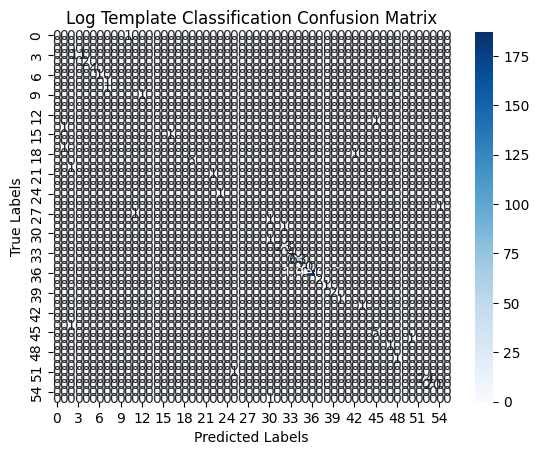

In [197]:
cm=confusion_matrix(y_test,pred_classes)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm,annot=True, cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Log Template Classification Confusion Matrix')
plt.show()

In [203]:
errors=(y_test!=pred_classes)
import pandas as pd
# from sklearn.preprocessing import LabelEncoder
# label_encoder=LabelEncoder()
output=pd.DataFrame({
    'actual':scaler.inverse_transform(y_test[errors]),
    'predicted':scaler.inverse_transform(pred_classes[errors])
})

output

,actual,predicted
0,audit: initializing netlink socket (disabled),audit(<*>.<*>:<*>): initialized
1,"DMA zone: <*> pages, LIFO batch:<*>",ACPI: ACPI tables contain no PCI IRQ routing e...
2,ACPI disabled because your bios is from <*> an...,CPU: Intel Pentium III (Coppermine) stepping <*>
3,sdpd startup succeeded,SELinux: Starting in permissive mode
4,mapped 4G/4G trampoline to <*>.,ACPI: Subsystem revision <*>
5,Transparent bridge - <*>,usbcore: registered new driver usbfs
6,User unknown timed out after <*> seconds at <*...,Calibrating delay loop... <*>.<*> BogoMIPS
7,Enabling fast FPU save and restore... done.,Enabling unmasked SIMD FPU exception support.....
8,Couldn't authenticate user,notify question section contains no SOA
9,rpc.idmapd startup succeeded,restart.


In [204]:
output.shape

(22, 2)